# Interpretacion fisico-operativa

Reporte compacto de los artefactos generados por `conclusion/build_physical_operational_artifacts.py`.

In [3]:
from pathlib import Path
from IPython.display import Image, display
import pandas as pd

PROJECT_ROOT = Path.cwd()
root_marker = Path('conclusion') / 'build_conclusion_artifacts.py'
if not (PROJECT_ROOT / root_marker).exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / root_marker).exists():
            PROJECT_ROOT = parent
            break
if not (PROJECT_ROOT / root_marker).exists():
    raise RuntimeError(
        f'No se encontro la carpeta conclusion/ desde {Path.cwd()}. '
        'Abri el notebook desde la raiz del repo TPF-ML o ejecuta primero: '
        'python conclusion/build_physical_operational_artifacts.py'
    )
CONCLUSION_DIR = PROJECT_ROOT / 'conclusion'
FIGURES_DIR = CONCLUSION_DIR / 'figures'


In [4]:
dictionary = pd.read_csv(CONCLUSION_DIR / 'physical_sensor_dictionary.csv')
importance_overall = pd.read_csv(CONCLUSION_DIR / 'physical_feature_importance_overall.csv')
importance_by_dataset = pd.read_csv(CONCLUSION_DIR / 'physical_feature_importance_by_dataset.csv')
sensitivity = pd.read_csv(CONCLUSION_DIR / 'physical_perturbation_sensitivity.csv')
pattern_links = pd.read_csv(CONCLUSION_DIR / 'physical_pattern_links.csv')


## Diccionario fisico


In [5]:
dictionary.head(24)


,raw_variable,physical_symbol,physical_description,engine_area,interpretation_for_rul
0,sensor_1,T2,Total temperature at fan inlet.,inlet/fan,Context signal for inlet thermodynamic state.
1,sensor_2,T24,Total temperature at LPC outlet.,LPC,Temperature changes can reflect compression ef...
2,sensor_3,T30,Total temperature at HPC outlet.,HPC,HPC outlet temperature is a degradation-sensit...
3,sensor_4,T50,Total temperature at LPT outlet.,turbine/LPT,Turbine outlet temperature can shift as effici...
4,sensor_5,P2,Pressure at fan inlet.,inlet/fan,Context signal for inlet pressure and operatin...
5,sensor_6,P15,Total pressure in bypass duct.,bypass,Bypass pressure can reflect fan/bypass operati...
6,sensor_7,P30,Total pressure at HPC outlet.,HPC,HPC outlet pressure is directly tied to compre...
7,sensor_8,Nf,Physical fan speed.,fan/spool,Fan speed variation helps separate regime and ...
8,sensor_9,Nc,Physical core speed.,core spool,Core speed dynamics are informative for degrad...
9,sensor_10,epr,Engine pressure ratio.,global engine pressure,Global pressure ratio summarizes engine pressu...


## Ranking global de importancia fisica


In [6]:
importance_overall.loc[importance_overall['base_variable'].str.startswith('sensor_')].head(12)


,base_variable,physical_symbol,physical_description,engine_area,mean_importance_normalized,max_importance_normalized,datasets_where_present,overall_rank
0,sensor_11,Ps30,Static pressure at HPC outlet.,HPC,0.236671,0.494772,"FD001,FD002,FD003,FD004",1
1,sensor_4,T50,Total temperature at LPT outlet.,turbine/LPT,0.091709,0.132719,"FD001,FD002,FD003,FD004",2
2,sensor_13,NRf,Corrected fan speed.,fan/spool,0.084684,0.161719,"FD001,FD002,FD003,FD004",3
3,sensor_8,Nf,Physical fan speed.,fan/spool,0.064462,0.118810,"FD001,FD002,FD003,FD004",4
4,sensor_14,NRc,Corrected core speed.,core spool,0.062495,0.084890,"FD001,FD002,FD003,FD004",5
5,sensor_9,Nc,Physical core speed.,core spool,0.060058,0.092060,"FD001,FD002,FD003,FD004",6
6,sensor_15,BPR,Bypass ratio.,bypass/fan,0.057428,0.099515,"FD001,FD002,FD003,FD004",7
7,sensor_3,T30,Total temperature at HPC outlet.,HPC,0.044468,0.069725,"FD001,FD002,FD003,FD004",8
8,sensor_12,phi,Ratio of fuel flow to Ps30.,fuel/HPC interaction,0.044445,0.088901,"FD001,FD002,FD003,FD004",9
9,sensor_2,T24,Total temperature at LPC outlet.,LPC,0.044195,0.061978,"FD001,FD002,FD003,FD004",10


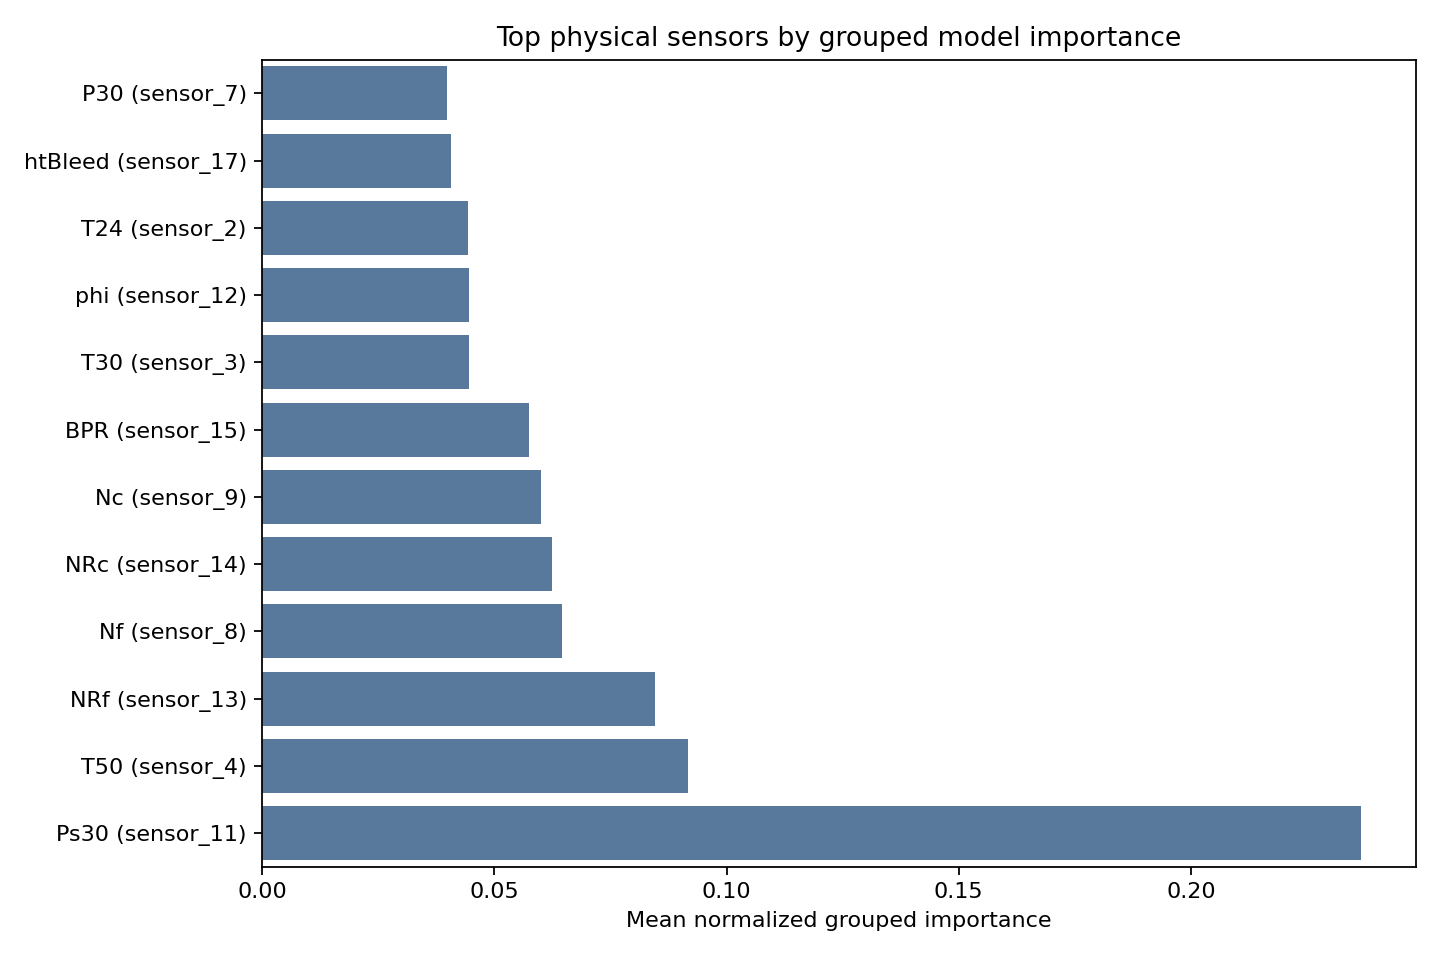

In [7]:
display(Image(filename=str(FIGURES_DIR / 'physical_feature_importance_top_sensors.png')))


## Ranking por subset


In [8]:
importance_by_dataset.sort_values(['dataset', 'rank_in_dataset']).groupby('dataset').head(8)


,dataset,base_variable,physical_symbol,physical_description,engine_area,importance_sum,importance_normalized,rank_in_dataset,n_derived_features
0,FD001,sensor_14,NRc,Corrected core speed.,core spool,1545.000000,0.084890,1,7
1,FD001,sensor_4,T50,Total temperature at LPT outlet.,turbine/LPT,1473.000000,0.080934,2,7
2,FD001,sensor_11,Ps30,Static pressure at HPC outlet.,HPC,1403.000000,0.077088,3,7
3,FD001,sensor_9,Nc,Physical core speed.,core spool,1350.000000,0.074176,4,7
4,FD001,sensor_3,T30,Total temperature at HPC outlet.,HPC,1269.000000,0.069725,5,7
5,FD001,sensor_7,P30,Total pressure at HPC outlet.,HPC,1187.000000,0.065220,6,7
6,FD001,sensor_12,phi,Ratio of fuel flow to Ps30.,fuel/HPC interaction,1130.000000,0.062088,7,7
7,FD001,setting_1,setting_1,Operational setting associated with flight reg...,operating condition,1118.000000,0.061429,8,7
17,FD002,sensor_11,Ps30,Static pressure at HPC outlet.,HPC,0.494772,0.494772,1,25
18,FD002,sensor_15,BPR,Bypass ratio.,bypass/fan,0.099515,0.099515,2,25


## Sensibilidad por perturbacion


In [9]:
sensitivity.sort_values(['delta_cmapss_score', 'mean_abs_prediction_shift'], ascending=False).head(15)


,dataset,base_variable,physical_symbol,physical_description,engine_area,baseline_mae,perturbed_mae,delta_mae,baseline_rmse,perturbed_rmse,...,perturbed_r2,delta_r2,baseline_cmapss_score,perturbed_cmapss_score,delta_cmapss_score,baseline_dangerous_error_pct,perturbed_dangerous_error_pct,delta_dangerous_error_pct,mean_abs_prediction_shift,n_perturbed_features
36,FD004,sensor_11,Ps30,Static pressure at HPC outlet.,HPC,17.909395,27.915996,10.006601,26.071138,35.908403,...,0.566269,-0.205093,4600.217417,18430.453817,13830.236400,6.451613,22.580645,16.129032,15.452605,25
12,FD002,sensor_11,Ps30,Static pressure at HPC outlet.,HPC,16.618845,24.373923,7.755078,25.280093,32.895975,...,0.625835,-0.153194,5349.925448,15420.862995,10070.937547,5.019305,18.532819,13.513514,12.954556,25
13,FD002,sensor_15,BPR,Bypass ratio.,bypass/fan,16.618845,20.574927,3.956082,25.280093,28.233734,...,0.724378,-0.054651,5349.925448,8163.560283,2813.634835,5.019305,8.494208,3.474903,8.792224,25
37,FD004,sensor_14,NRc,Corrected core speed.,core spool,17.909395,20.191603,2.282208,26.071138,28.637705,...,0.724130,-0.047232,4600.217417,7385.770607,2785.553191,6.451613,8.467742,2.016129,4.719556,26
38,FD004,sensor_4,T50,Total temperature at LPT outlet.,turbine/LPT,17.909395,22.218105,4.308710,26.071138,29.793068,...,0.701422,-0.069941,4600.217417,7128.841670,2528.624253,6.451613,15.725806,9.274194,7.780340,25
14,FD002,sensor_4,T50,Total temperature at LPT outlet.,turbine/LPT,16.618845,19.562350,2.943505,25.280093,27.421675,...,0.740004,-0.039025,5349.925448,7530.873096,2180.947649,5.019305,7.722008,2.702703,6.481019,25
15,FD002,sensor_8,Nf,Physical fan speed.,fan/spool,16.618845,18.648078,2.029232,25.280093,27.387959,...,0.740643,-0.038386,5349.925448,7427.392062,2077.466615,5.019305,5.791506,0.772201,4.675154,24
39,FD004,sensor_9,Nc,Physical core speed.,core spool,17.909395,19.621091,1.711695,26.071138,27.990677,...,0.736455,-0.034907,4600.217417,6129.723136,1529.505719,6.451613,6.854839,0.403226,4.877597,26
16,FD002,sensor_14,NRc,Corrected core speed.,core spool,16.618845,18.107512,1.488667,25.280093,26.933875,...,0.749172,-0.029857,5349.925448,6774.150376,1424.224929,5.019305,6.563707,1.544402,3.749168,26
40,FD004,sensor_13,NRf,Corrected fan speed.,fan/spool,17.909395,20.787566,2.878171,26.071138,28.197113,...,0.732553,-0.038809,4600.217417,5823.227967,1223.010550,6.451613,13.306452,6.854839,5.130689,14


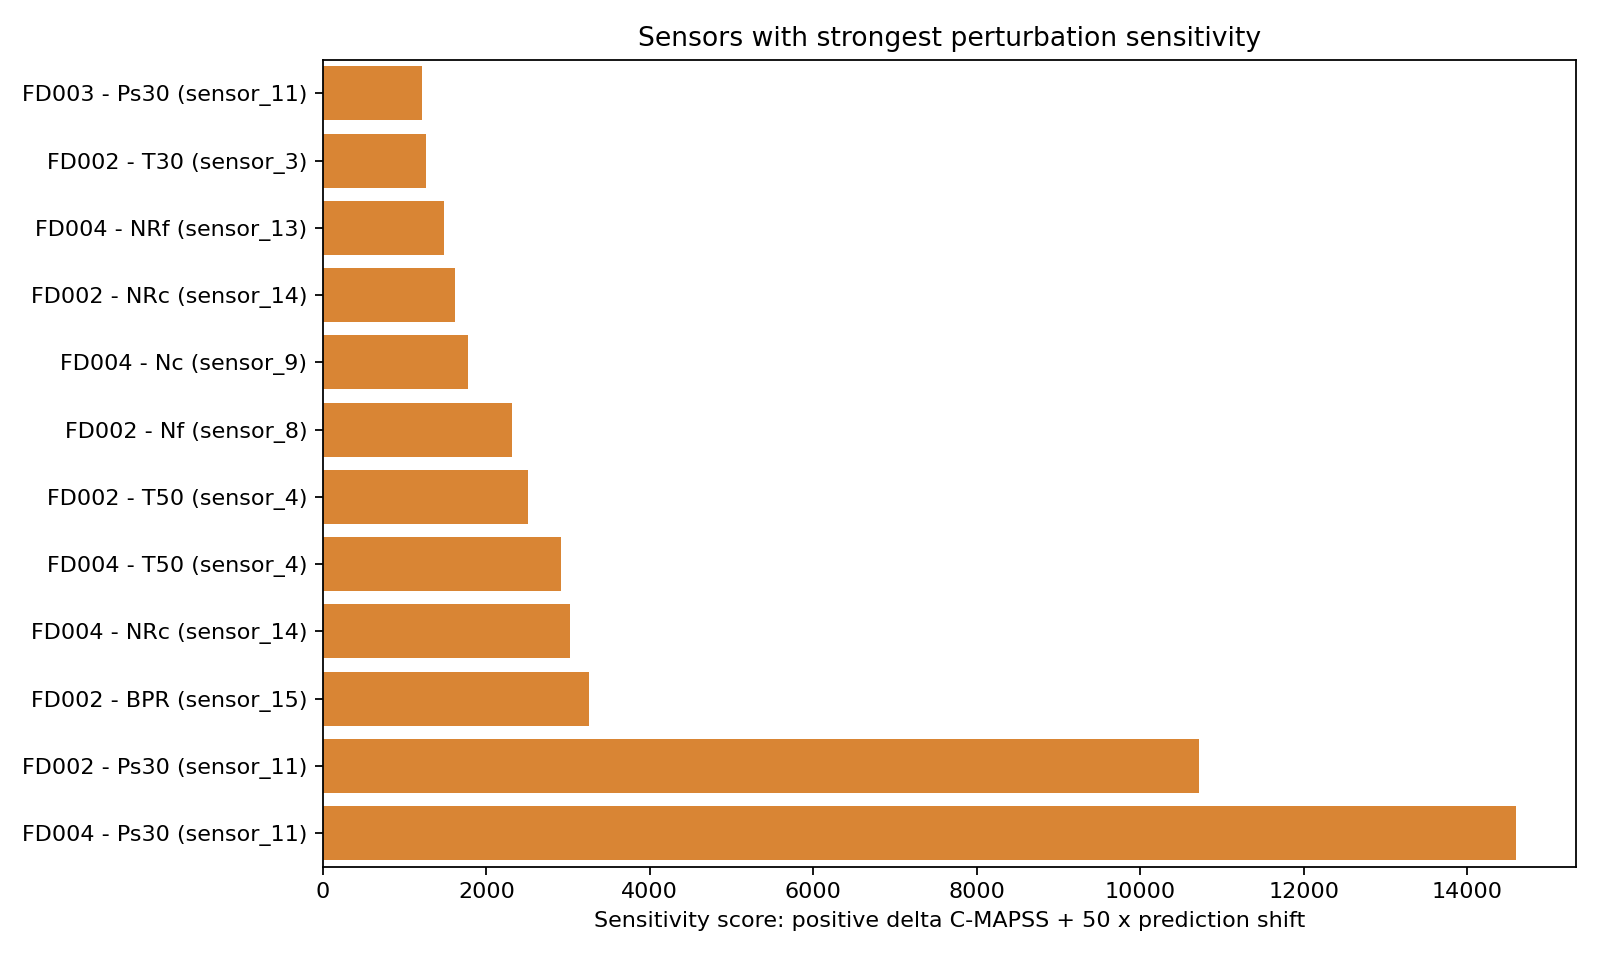

In [10]:
display(Image(filename=str(FIGURES_DIR / 'physical_perturbation_sensitivity_top_sensors.png')))


## Conexion con patrones FD003/FD004


In [11]:
pattern_links


,dataset,pattern_source,base_variable,physical_symbol,physical_description,engine_area,interpretation
0,FD003,notas/hallazgos/FD003/hallazgo_clusters_fd003.txt,sensor_9,Nc,Physical core speed.,core spool,Clusters exploratorios con una sola condicion ...
1,FD003,notas/hallazgos/FD003/hallazgo_clusters_fd003.txt,sensor_14,NRc,Corrected core speed.,core spool,Clusters exploratorios con una sola condicion ...
2,FD003,notas/hallazgos/FD003/hallazgo_clusters_fd003.txt,sensor_7,P30,Total pressure at HPC outlet.,HPC,Clusters exploratorios con una sola condicion ...
3,FD003,notas/FD003/fd003_internal_validation_evaluati...,sensor_7,P30,Total pressure at HPC outlet.,HPC,Features fault-sensitive calculadas sin mirar ...
4,FD003,notas/FD003/fd003_internal_validation_evaluati...,sensor_9,Nc,Physical core speed.,core spool,Features fault-sensitive calculadas sin mirar ...
5,FD003,notas/FD003/fd003_internal_validation_evaluati...,sensor_12,phi,Ratio of fuel flow to Ps30.,fuel/HPC interaction,Features fault-sensitive calculadas sin mirar ...
6,FD003,notas/FD003/fd003_internal_validation_evaluati...,sensor_14,NRc,Corrected core speed.,core spool,Features fault-sensitive calculadas sin mirar ...
7,FD003,notas/FD003/fd003_internal_validation_evaluati...,sensor_15,BPR,Bypass ratio.,bypass/fan,Features fault-sensitive calculadas sin mirar ...
8,FD004,notas/hallazgos/FD004/hallazgo_fd004_condition...,sensor_11,Ps30,Static pressure at HPC outlet.,HPC,Al normalizar por condicion reaparecen sensore...
9,FD004,notas/hallazgos/FD004/hallazgo_fd004_condition...,sensor_4,T50,Total temperature at LPT outlet.,turbine/LPT,Al normalizar por condicion reaparecen sensore...
